# Random Forest Model - EDP

### Importing necessary libraries

In [30]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from collections import Counter

### Loading and Preprocessing Data for Classification

In [35]:
# Set the data directory
base_directory = r"D:\Learning\eye disease prediction\dataset"
# Load and preprocess images, and label them
image_data = []
labels = []
image_extensions = ('.jpg', '.jpeg', '.png')
# Define class names
class_names = ["glaucoma", "cataract", "normal", "diabetic_retinopathy"] 
for class_name in class_names:
    class_directory = os.path.join(base_directory, class_name)
    for file in os.listdir(class_directory):
        if file.endswith(image_extensions):
            image_path = os.path.join(class_directory, file)
            
            # Label is the index of the class name in class_names
            label = class_names.index(class_name)
            
            # Preprocess the image (e.g., resize, normalize, convert to grayscale, etc.)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = cv2.resize(image, (128, 128))  # Adjust the size as needed
            image = image / 255.0  # Normalize pixel values

            image_data.append(image)
            labels.append(label)

In [34]:
base_directory = r"D:\Learning\eye disease prediction\dataset"
for class_name in class_names:
    class_directory = os.path.join(base_directory, class_name)
    print(class_directory)

D:\Learning\eye disease prediction\dataset\glaucoma
D:\Learning\eye disease prediction\dataset\cataract
D:\Learning\eye disease prediction\dataset\normal
D:\Learning\eye disease prediction\dataset\diabetic_retinopathy


In [36]:
label_series = pd.Series(labels)
print(label_series.value_counts())

3    1098
2    1074
1    1038
0    1007
Name: count, dtype: int64


### Dataset Visualization

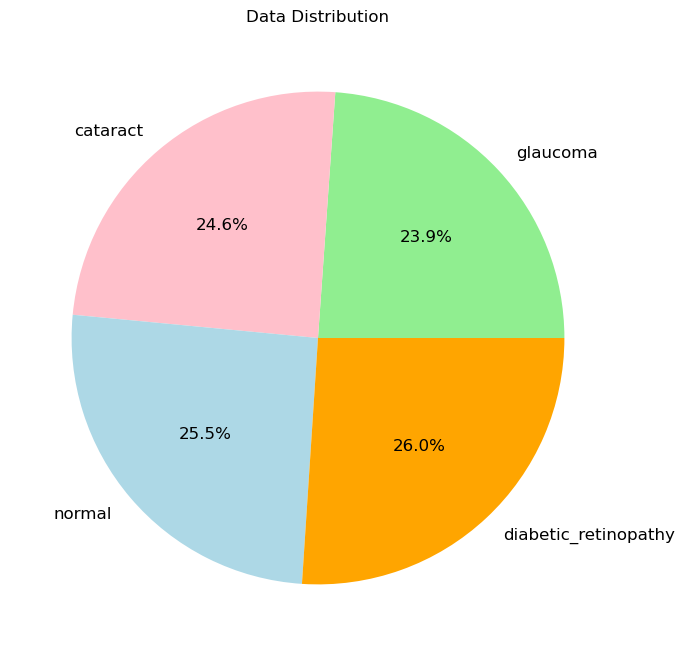

In [12]:
import matplotlib.pyplot as plt

count_for_class_0 = 1007  
count_for_class_1 = 1038 
count_for_class_2 = 1074 
count_for_class_3 = 1098  

# Create a list with the counts
class_counts = [count_for_class_0, count_for_class_1, count_for_class_2, count_for_class_3]

# Define colors for the pie chart
colors = ['lightgreen', 'pink', 'lightblue', 'orange']  # Use 'lightblue' and 'lightgreen'

# Specify text properties
text_props = {'color': 'black', 'fontsize': 12}  # Change text color to black

# Plot the data distribution as a pie chart with light blue background
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_names, autopct='%1.1f%%', colors=colors, textprops=text_props)
plt.title('Data Distribution')
plt.gca().set_facecolor('lightblue')  # Set light blue background
plt.show()

### Spliiting the data and flattening the images

In [37]:
# Split the data into training and testing sets
X = np.array(image_data)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)


In [38]:
X.shape,y.shape

((4217, 128, 128), (4217,))

In [39]:
# Flatten the image data
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


In [40]:
X_train.shape

(3373, 16384)

In [41]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.00392157,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157]])

### Creating and training Random Forest classifier

In [42]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
# Make predictions on the testing data
y_pred = clf.predict(X_test)

### Evaluating the model

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7440758293838863


In [45]:
unique_classes_y_test = np.unique(y_test)
unique_classes_y_pred = np.unique(y_pred)

print("Unique classes in y_test:", unique_classes_y_test)
print("Unique classes in y_pred:", unique_classes_y_pred)


Unique classes in y_test: [0 1 2 3]
Unique classes in y_pred: [0 1 2 3]


### Generating classification report

In [46]:
from sklearn.metrics import classification_report

# Generate a classification report with the 'labels' parameter
report = classification_report(y_test, y_pred, labels=np.unique(y_test), target_names=class_names)

# Print the classification report
print(report)

                      precision    recall  f1-score   support

            glaucoma       0.73      0.56      0.63       226
            cataract       0.74      0.58      0.65       214
              normal       0.59      0.88      0.71       201
diabetic_retinopathy       0.99      0.98      0.99       203

            accuracy                           0.74       844
           macro avg       0.76      0.75      0.75       844
        weighted avg       0.76      0.74      0.74       844



In [48]:
from sklearn.metrics import confusion_matrix

# confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

In [49]:
print(cm)

[[127  33  66   0]
 [ 34 125  55   0]
 [ 11  12 177   1]
 [  3   0   1 199]]


In [52]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(class_names))))

In [54]:
cm

array([[127,  33,  66,   0],
       [ 34, 125,  55,   0],
       [ 11,  12, 177,   1],
       [  3,   0,   1, 199]], dtype=int64)

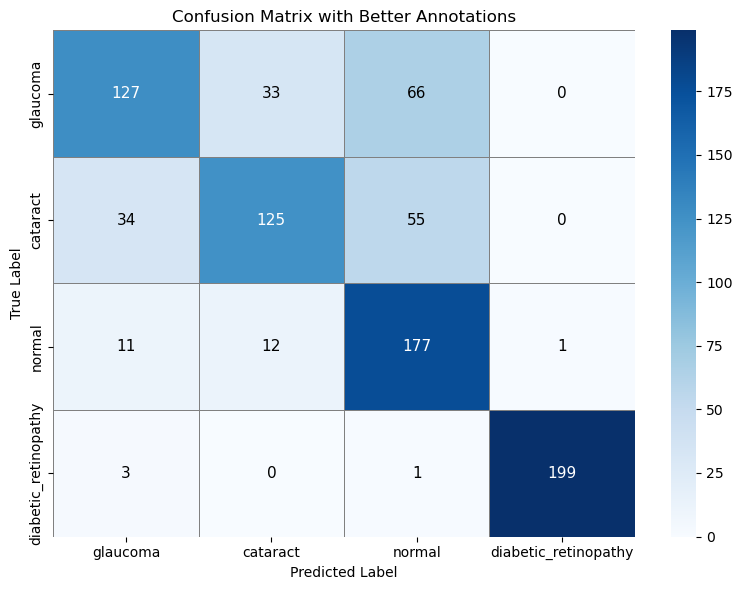

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix (force full matrix)
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(class_names))))

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names,
                 linewidths=0.5, linecolor='gray')

# Annotate each cell manually with color contrast
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        # Choose annotation color based on cell intensity
        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(value),
                ha='center', va='center', color=text_color, fontsize=11)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix with Better Annotations')
plt.tight_layout()
plt.show()

In [2]:
import pickle

In [13]:
pickle.dump(clf,open('rf_model.pkl','wb'))